Датасет: Red Wine Quality<br>
Описание: This datasets is related to red variants of the Portuguese "Vinho Verde" wine. For more details, consult the reference [Cortez et al., 2009]. Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).<br>
[Ссылка на датасет](https://www.kaggle.com/code/nimapourmoradi/red-wine-quality)

In [1]:
import sys
import platform
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


%matplotlib inline

try:
    import sklearn
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.feature_extraction import FeatureHasher
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)

Python: 3.12.3
Executable: /media/chalandbek/4 soft/4soft/gcppc/ml-course-homeworks/.venv/bin/python
OS: Linux-6.17.0-19-generic-x86_64-with-glibc2.39
NumPy: 2.4.2
Pandas: 3.0.1
scikit-learn: 1.8.0


Загрузка датасета

In [2]:
rwq = pd.read_csv('winequality-red.csv')
print(rwq.shape)

(1599, 12)


### Проверка датасета<br>
* Датасет содержит 12 признаков
* 11 признаков типа float64 и 1 типа int64
* Датасет содержит 1599 объектов
* Ни один из объектов не содержит пропуски

In [3]:
print('Пропуски:')
print(rwq.isnull().sum())
print('\nИнформация:')
print(rwq.info())

Пропуски:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Информация:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   flo

Вывод дисперсии, асимметрии и эксцесса всех данных для обнаружения явных проблем.
Из этого видно следующее:
* Общий диоксид серы и свободный диоксид серы имеют невероятно высокую дисперсию
* Хлориды, остаточный сахар и сульфаты имеют высокие значения асимметрии и эксцесса.


In [4]:
for colName in rwq.columns.tolist():
    col = rwq[colName]
    print(colName,':')
    print('\tVariance: ', col.var())
    print('\tSkewness: ', col.skew())
    print('\tKurtosis: ', col.kurt())

fixed acidity :
	Variance:  3.0314163889978167
	Skewness:  0.9827514413284587
	Kurtosis:  1.1321433977276252
volatile acidity :
	Variance:  0.032062377651551614
	Skewness:  0.6715925723840199
	Kurtosis:  1.2255422501791422
citric acid :
	Variance:  0.03794748313440581
	Skewness:  0.3183372952546368
	Kurtosis:  -0.7889975153633966
residual sugar :
	Variance:  1.9878971329859634
	Skewness:  4.54065542590319
	Kurtosis:  28.617595424475443
chlorides :
	Variance:  0.0022151426533009912
	Skewness:  5.680346571971722
	Kurtosis:  41.7157872475766
free sulfur dioxide :
	Variance:  109.414883833059
	Skewness:  1.250567293314441
	Kurtosis:  2.023562045840575
total sulfur dioxide :
	Variance:  1082.1023725325824
	Skewness:  1.515531257594554
	Kurtosis:  3.8098244878645744
density :
	Variance:  3.562029453326973e-06
	Skewness:  0.07128766294927483
	Kurtosis:  0.9340790654648123
pH :
	Variance:  0.023835180545412844
	Skewness:  0.19368349811284427
	Kurtosis:  0.806942508246574
sulphates :
	Variance:

Между собой не слабо так кореллируют
* лимонная кислота и фиксированная кислотность (что очевидно)
* плотность и фиксированная кислотность
* свободный диоксид серы и total sulfur dioxide (что тоже очевидно)

Из приятного, прослеживается корелляция общего уровня качества с алкоголем. <br>
Тем не менее, некоторые признаки кореллируют между собой, что может стать проблемой.

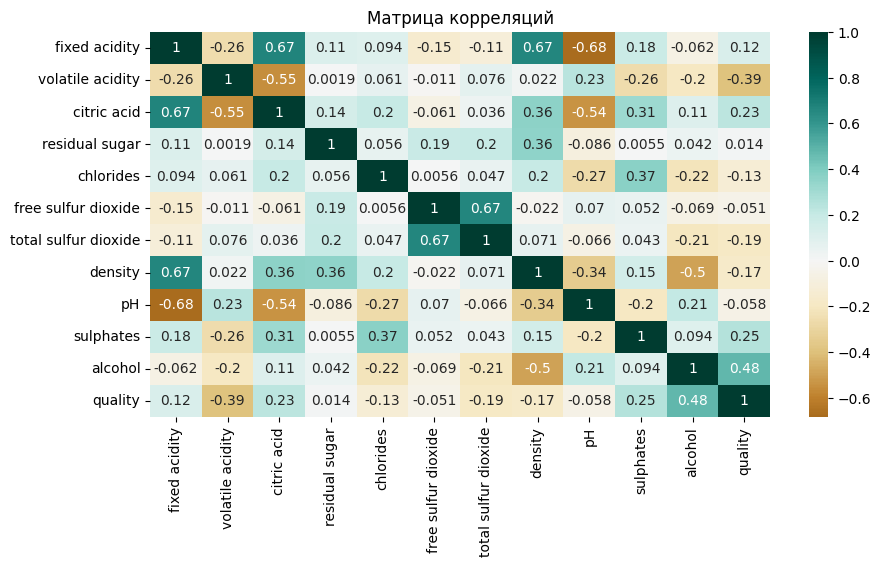

In [5]:
plt.figure(figsize=(10, 5))
sns.heatmap(rwq.corr(), annot=True, cmap='BrBG', center=0)
plt.title('Матрица корреляций')
plt.show()


In [6]:
rwqn = rwq.copy()
colsToDrop = ['free sulfur dioxide', 'pH', 'residual sugar','citric acid']
rwqn = rwqn.drop(columns=colsToDrop)

Разделение на train, test и val.<br>
Разделение 60/40.<br>
Подбирать параметры на тестовой выборке ни в коем случае, очевидно, нельзя, поскольку это приведет к переобучению; модель будет хорошо обучена проходить именно тесты и так себе обучена проходить <u>не тесты<u>.

In [7]:
X = rwq.drop('quality', axis=1)
Y = rwq['quality']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)
print(X_train.shape)
print(X_test.shape)


(959, 11)
(640, 11)


In [8]:
Xn = rwqn.drop('quality', axis=1)
Yn = rwqn['quality']

Xn_train, Xn_test, Yn_train, Yn_test = train_test_split(Xn, Yn, test_size=0.4, random_state=42)

Категориальные признаки в датасете отсутствуют, пропусков также нет.
### Масштабирование признаков
При работе с наборами данных с несколькими признаками некоторые признаки могут иметь больший масштаб, чем другие. В KNN это особенно важно, поскльку алгоритм работает с расстояниями и без масштабирования признаков результаты могут быть искажены, поскольку не все признаки будут влиять на результат равным образом.

In [9]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [10]:
scaler = StandardScaler()
scaler.fit(Xn_train)
Xn_train_scaled = scaler.transform(Xn_train)
Xn_test_scaled = scaler.transform(Xn_test)

Функция, которая просто перебирает кучу вариантов параметров для knn (k от 1 до 30, 3 метрики, 2 типа весов)

In [11]:
def knnResearch(X_train_scaled, Y_train, X_test_scaled, Y_test):
    results = []
    ps = {
        'euclidean' : 2,
        'manhattan' : 1,
        'minkowski' : 3
    }
    for k in range(1, 31):
        for metric in ['euclidean', 'manhattan', 'minkowski']:
            for weights in ['uniform', 'distance']:
                startTime = time.time()
                knn = KNeighborsClassifier(
                    n_neighbors=k,
                    metric=metric,
                    weights=weights,
                    p = ps[metric]
                )
                knn.fit(X_train_scaled, Y_train)

                Y_pred = knn.predict(X_test_scaled)
                accuracy = accuracy_score(Y_test, Y_pred)
                
                totalTime = time.time() - startTime

                results.append({
                    'k' : k,
                    'metric' : metric,
                    'weights' : weights,
                    'accuracy' : accuracy,
                    'time' : totalTime
                }
                )

    return pd.DataFrame(results)

Вызов функции анализа для всех вариантов датасета.

In [12]:
res = knnResearch(X_train_scaled, Y_train, X_test_scaled, Y_test)
print('Лучший резулльтат (полный масштабированный датасет):')
print(res.loc[res['accuracy'].idxmax()])

resn = knnResearch(Xn_train_scaled, Yn_train, Xn_test_scaled, Yn_test)
print('Лучший резулльтат (неполный масштабированный датасет):')
print(resn.loc[resn['accuracy'].idxmax()])

resus = knnResearch(X_train, Y_train, X_test, Y_test)
print('Лучший резулльтат (полный немасштабированный датасет):')
print(resus.loc[resus['accuracy'].idxmax()])

resnus = knnResearch(Xn_train, Yn_train, Xn_test, Yn_test)
print('Лучший резулльтат (неполный немасштабированный датасет):')
print(resnus.loc[resnus['accuracy'].idxmax()])


Лучший резулльтат (полный масштабированный датасет):
k                   9
metric      minkowski
weights      distance
accuracy     0.634375
time         0.067283
Name: 53, dtype: object
Лучший резулльтат (неполный масштабированный датасет):
k                  28
metric      euclidean
weights      distance
accuracy     0.654687
time         0.007875
Name: 163, dtype: object
Лучший резулльтат (полный немасштабированный датасет):
k                  28
metric      manhattan
weights      distance
accuracy          0.6
time         0.006838
Name: 165, dtype: object
Лучший резулльтат (неполный немасштабированный датасет):
k                  29
metric      manhattan
weights      distance
accuracy     0.598437
time         0.005253
Name: 171, dtype: object


### Вы<b>воды</b>
В ходе выполнения сего ноутбука был рассмотрен известный датасет "red wine quality". Был проанализирован как сам датасет, так и knn при ращличных параметрах (k, метрика, тип весов). Наибольшее значение точности было достигнуто при масштабировании датасета и удалении ииз него кореллирующих между собой признаков: 65% (иишка от гугла сказала, что для этого датасета это неплохой результат). Масштабирование признаков повышало
точность на 3-5%. Удаление неугодных признаков - на 2%. Наиболее эффективные метрики зависили от ситуации, но при лучших результатах веса всегда были взвешенные.